In [1]:
%load_ext rpy2.ipython

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from babel import Locale
import matplotlib.ticker as mticker


df = pd.read_parquet("../../data/processed/theses-soutenues-enhanced[full_data].parquet")

Error importing in API mode: ImportError("dlopen(/Users/admin/Projects/phd-theses-france/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B6AFC42B-ACF3-390A-BF82-02CCC819CD1A> /Users/admin/Projects/phd-theses-france/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [26]:
# Set publication style with greyscale default for both seaborn and matplotlib
sns.set_style("whitegrid")
sns.set_palette("Greys_r")  # Reversed greyscale palette
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Greys(np.linspace(0.3, 0.9, 10)))

In [2]:
pd.set_option('display.max_columns', None)
df.head()

,accessible,cas,code_etab,date_soutenance,discipline,embargo,nnt,source,sujets_rameau,these_sur_travaux,from_api,auteur.idref,auteur.nom,auteur.prenom,auteur.gender,auteur.birthdate,auteur.deathdate,auteur.languages,auteur.country,auteur.age,directeur.0.idref,directeur.0.nom,directeur.0.prenom,directeur.0.gender,directeur.0.birthdate,directeur.0.deathdate,directeur.0.languages,directeur.0.country,directeur.0.centrality,directeur.0.age,directeur.0.yrs_since_phd,directeur.0.yrs_since_first_jury,directeur.1.idref,directeur.1.nom,directeur.1.prenom,directeur.1.gender,directeur.1.birthdate,directeur.1.deathdate,directeur.1.languages,directeur.1.country,directeur.1.centrality,directeur.1.age,directeur.1.yrs_since_phd,directeur.1.yrs_since_first_jury,directeur.2.idref,directeur.2.nom,directeur.2.prenom,directeur.2.gender,directeur.2.birthdate,directeur.2.deathdate,directeur.2.languages,directeur.2.country,directeur.2.centrality,directeur.2.age,directeur.2.yrs_since_phd,directeur.2.yrs_since_first_jury,directeur.3.idref,directeur.3.nom,directeur.3.prenom,directeur.3.gender,directeur.3.birthdate,directeur.3.deathdate,directeur.3.languages,directeur.3.country,directeur.3.centrality,directeur.3.age,directeur.3.yrs_since_phd,directeur.3.yrs_since_first_jury,directeur.4.idref,directeur.4.nom,directeur.4.prenom,directeur.4.gender,directeur.4.birthdate,directeur.4.deathdate,directeur.4.languages,directeur.4.country,directeur.4.centrality,directeur.4.age,directeur.4.yrs_since_phd,directeur.4.yrs_since_first_jury,directeur.5.idref,directeur.5.nom,directeur.5.prenom,directeur.5.gender,directeur.5.birthdate,directeur.5.deathdate,directeur.5.languages,directeur.5.country,directeur.5.centrality,directeur.5.age,directeur.5.yrs_since_phd,directeur.5.yrs_since_first_jury,directeur.6.idref,directeur.6.nom,directeur.6.prenom,directeur.6.gender,directeur.6.birthdate,directeur.6.deathdate,directeur.6.languages,directeur.6.country,membre_jury.0.idref,membre_jury.0.nom,membre_jury.0.prenom,membre_jury.0.gender,membre_jury.0.birthdate,membre_jury.0.deathdate,membre_jury.0.languages,membre_jury.0.country,membre_jury.0.centrality,membre_jury.0.age,membre_jury.0.yrs_since_phd,membre_jury.0.yrs_since_first_jury,membre_jury.1.idref,membre_jury.1.nom,membre_jury.1.prenom,membre_jury.1.gender,membre_jury.1.birthdate,membre_jury.1.deathdate,membre_jury.1.languages,membre_jury.1.country,membre_jury.1.centrality,membre_jury.1.age,membre_jury.1.yrs_since_phd,membre_jury.1.yrs_since_first_jury,membre_jury.2.idref,membre_jury.2.nom,membre_jury.2.prenom,membre_jury.2.gender,membre_jury.2.birthdate,membre_jury.2.deathdate,membre_jury.2.languages,membre_jury.2.country,membre_jury.2.centrality,membre_jury.2.age,membre_jury.2.yrs_since_phd,membre_jury.2.yrs_since_first_jury,membre_jury.3.idref,membre_jury.3.nom,membre_jury.3.prenom,membre_jury.3.gender,membre_jury.3.birthdate,membre_jury.3.deathdate,membre_jury.3.languages,membre_jury.3.country,membre_jury.3.centrality,membre_jury.3.age,membre_jury.3.yrs_since_phd,membre_jury.3.yrs_since_first_jury,membre_jury.4.idref,membre_jury.4.nom,membre_jury.4.prenom,membre_jury.4.gender,membre_jury.4.birthdate,membre_jury.4.deathdate,membre_jury.4.languages,membre_jury.4.country,membre_jury.4.centrality,membre_jury.4.age,membre_jury.4.yrs_since_phd,membre_jury.4.yrs_since_first_jury,membre_jury.5.idref,membre_jury.5.nom,membre_jury.5.prenom,membre_jury.5.gender,membre_jury.5.birthdate,membre_jury.5.deathdate,membre_jury.5.languages,membre_jury.5.country,membre_jury.5.centrality,membre_jury.5.age,membre_jury.5.yrs_since_phd,membre_jury.5.yrs_since_first_jury,membre_jury.6.idref,membre_jury.6.nom,membre_jury.6.prenom,membre_jury.6.gender,membre_jury.6.birthdate,membre_jury.6.deathdate,membre_jury.6.languages,membre_jury.6.country,membre_jury.6.centrality,membre_jury.6.age,membre_jury.6.yrs_since_phd,membre_jury.6.yrs_since_first_jury,membre_jury.7.idref,membre_jury.7.nom,membre_jury.7.prenom,membre_jury.7.gender,membre_jury.7.birthdate,

In [3]:
%%R

library(naniar)
library(ggplot2)
library(dplyr)
library(arrow)

df = read_parquet("../../data/processed/theses-soutenues-enhanced[full_data].parquet")


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘arrow’

The following object is masked from ‘package:utils’:

    timestamp



In [4]:
%%R

library(dplyr)
library(naniar)

df_theses <- df %>%
  select(
    "accessible",
    "code_etab",
    "date_soutenance",
    "nnt",
    "tel",
    "ppn",
    "auteur.idref",
    "auteur.nom",
    "auteur.prenom",
    "auteur.gender",
    "auteur.birthdate",
    "auteur.languages",
    "auteur.country",
    "sujets.0",
    "sujets.1",
    "etablissement_soutenance.0.nom",
    "resume.0",
    "resume.1",
    "titre.0",
    "titre.1",
    "langue.0",
    "langue.1",
    "langue.2",
    "langue.3"
  )

df_theses <- df_theses %>%
  mutate(across(where(is.character), ~na_if(., "")))

# Data completion plots
## Data on theses missing

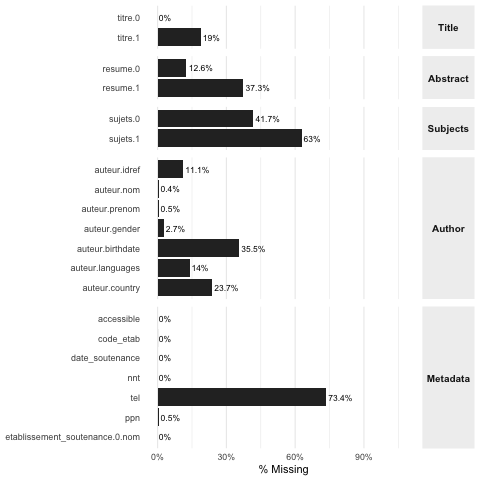

In [5]:
%%R
library(tidyr)

var_order <- c(
  "titre.0", "titre.1",
  "resume.0", "resume.1",
  "sujets.0", "sujets.1",
  "auteur.idref", "auteur.nom", "auteur.prenom",
  "auteur.gender", "auteur.birthdate", "auteur.languages", "auteur.country",
  "accessible", "code_etab", "date_soutenance", "nnt",
  "tel", "ppn",
  "etablissement_soutenance.0.nom"
)

groups <- tibble(
  variable = var_order,
  group = c(
    rep("Title", 2),
    rep("Abstract", 2),
    rep("Subjects", 2),
    rep("Author", 7),
    rep("Metadata", 7)
  )
) %>%
  mutate(
    variable = factor(variable, levels = rev(var_order)),
    group = factor(group, levels = c("Title", "Abstract", "Subjects", "Author", "Metadata"))
  )

miss_df <- df_theses %>%
  summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "pct_missing") %>%
  left_join(groups, by = "variable") %>%
  filter(!is.na(group)) %>%
  mutate(variable = factor(variable, levels = rev(var_order)))

p1 <- ggplot(miss_df, aes(x = variable, y = pct_missing)) +
  geom_col(fill = "#2c2c2c") +
  geom_text(aes(label = paste0(round(pct_missing, 1), "%")),
            hjust = -0.1, size = 3) +
  coord_flip() +
  facet_grid(group ~ ., scales = "free_y", space = "free_y") +
  scale_y_continuous(limits = c(0, 110), labels = function(x) paste0(x, "%")) +
  labs(x = NULL, y = "% Missing") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 9),
    panel.grid.major.y = element_blank(),
    strip.text.y = element_text(angle = 0, face = "bold", size = 10),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    panel.spacing = unit(0.5, "lines")
  )

print(p1)

## Data on supervisors and jury members missing

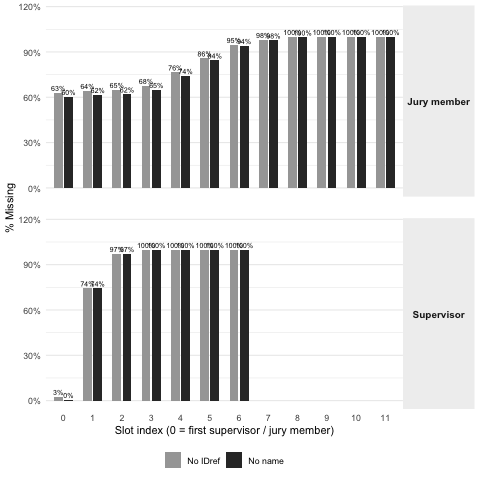

In [6]:
%%R
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)

role_patterns <- list(
  "Supervisor"  = "directeur\\.\\d+\\.(nom|idref|gender)",
  "Jury member" = "membre_jury\\.\\d+\\.(nom|idref|gender)"
)

miss_jury <- bind_rows(lapply(names(role_patterns), function(role) {
  pattern <- role_patterns[[role]]
  cols <- grep(pattern, colnames(df), value = TRUE)
  df %>%
    mutate(across(where(is.character), ~na_if(., ""))) %>%
    select(all_of(cols)) %>%
    summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "pct_missing") %>%
    mutate(
      role  = role,
      i     = as.integer(str_extract(variable, "(?<=\\.)\\d+(?=\\.)")),
      field = str_extract(variable, "[^.]+$")
    )
}))

p2 <- miss_jury %>%
  filter(field %in% c("nom", "idref")) %>%
  mutate(
    i     = factor(i),
    field = recode(field,
                   "nom"   = "No name",
                   "idref" = "No IDref")
  ) %>%
  ggplot(aes(x = i, y = pct_missing, fill = field)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  geom_text(aes(label = paste0(round(pct_missing), "%")),
            position = position_dodge(width = 0.7),
            vjust = -0.4, size = 2.5) +
  facet_grid(role ~ ., scales = "free_y", space = "free_y") +
  scale_y_continuous(limits = c(0, 115), labels = function(x) paste0(x, "%")) +
  scale_fill_manual(values = c(
    "No name"  = "grey20",
    "No IDref" = "grey65"
  )) +
  labs(
    x = "Slot index (0 = first supervisor / jury member)", y = "% Missing", fill = NULL
  ) +
  theme_minimal() +
  theme(
    panel.grid.major.x = element_blank(),
    strip.text.y = element_text(angle = 0, face = "bold", size = 10),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    panel.spacing = unit(1.5, "lines"),
    legend.position = "bottom"
  )

print(p2)

## Enriched data from IDref entries missing

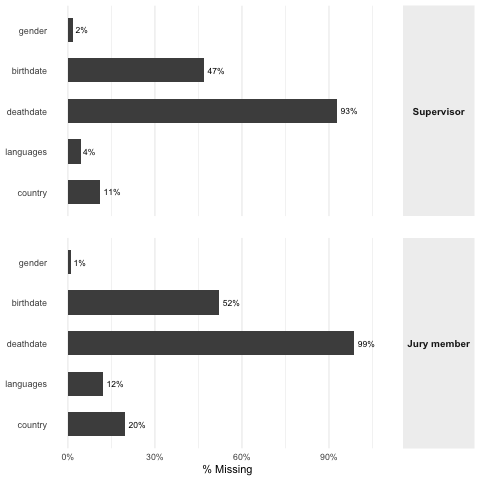

In [7]:
%%R
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)

jury_cols <- grep("^(directeur|membre_jury)\\.", colnames(df), value = TRUE)
df_jury <- df %>% select(all_of(jury_cols))

info_fields <- c("gender", "birthdate", "deathdate", "languages", "country")
field_order  <- rev(info_fields)

miss_conditional <- df_jury %>%
  mutate(thesis_id = row_number(),
         across(everything(), as.character)) %>%
  pivot_longer(-thesis_id, names_to = "variable", values_to = "value") %>%
  mutate(
    role  = str_extract(variable, "^[^.]+"),
    i     = as.integer(str_extract(variable, "(?<=\\.)(\\d+)(?=\\.)")),
    field = str_extract(variable, "[^.]+$")
  ) %>%
  group_by(thesis_id, role, i) %>%
  mutate(person_exists = any(field == "nom" & !is.na(value))) %>%
  ungroup() %>%
  filter(person_exists, field %in% info_fields) %>%
  group_by(role, field) %>%
  summarise(pct_missing = mean(is.na(value)) * 100, .groups = "drop") %>%
  mutate(
    field = factor(field, levels = field_order),
    role  = factor(role, levels = c("directeur", "membre_jury"),
                   labels = c("Supervisor", "Jury member"))
  )

p3 <- ggplot(miss_conditional, aes(x = field, y = pct_missing)) +
  geom_col(fill = "grey30", width = 0.6) +
  geom_text(aes(label = paste0(round(pct_missing), "%")),
            hjust = -0.2, size = 3) +
  coord_flip() +
  facet_grid(role ~ ., scales = "free_y", space = "free_y") +
  scale_y_continuous(limits = c(0, 110), labels = function(x) paste0(x, "%")) +
  labs(x = NULL, y = "% Missing") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 9),
    panel.grid.major.y = element_blank(),
    strip.text.y = element_text(angle = 0, face = "bold", size = 10),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    panel.spacing = unit(1.5, "lines")
  )

print(p3)

## Subjects entries missing

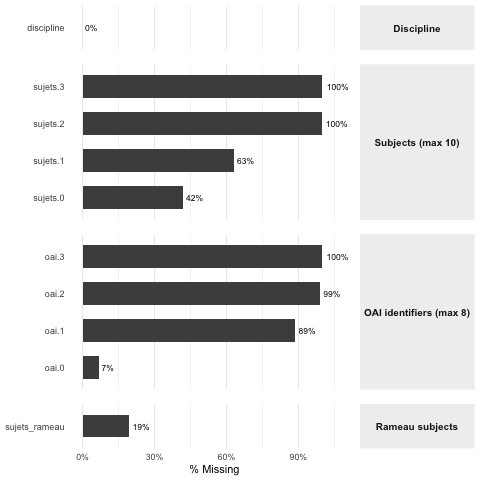

In [8]:
%%R

disc_miss <- df %>%
  mutate(across(where(is.character), ~na_if(., ""))) %>%
  summarise(pct_missing = mean(is.na(discipline)) * 100) %>%
  mutate(variable = "discipline", group = "Discipline")

overview_vars <- grep(
  "^(sujets\\.\\d+|oai\\.\\d+)$",
  colnames(df), value = TRUE
)

overview_miss <- df %>%
  mutate(across(where(is.character), ~na_if(., ""))) %>%
  select(all_of(overview_vars)) %>%
  summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "pct_missing") %>%
  mutate(
    group = case_when(
      str_starts(variable, "sujets") ~ "Subjects (max 10)",
      str_starts(variable, "oai")    ~ "OAI identifiers (max 8)"
    ),
    i = as.integer(str_extract(variable, "(?<=\\.)\\d+$"))
  ) %>%
  filter(
    (group == "Subjects (max 10)"       & i <= 3) |
    (group == "OAI identifiers (max 8)" & i <= 3)
  )

rameau_miss <- df %>%
  mutate(across(where(is.character), ~na_if(., ""))) %>%
  summarise(pct_missing = mean(is.na(sujets_rameau)) * 100) %>%
  mutate(variable = "sujets_rameau", group = "Rameau subjects", i = NA_integer_)

overview_all <- bind_rows(
  disc_miss %>% mutate(i = NA_integer_),
  overview_miss,
  rameau_miss
) %>%
  mutate(
    group = factor(group, levels = c(
      "Discipline", "Subjects (max 10)",
      "OAI identifiers (max 8)", "Rameau subjects"
    )),
    variable = factor(variable, levels = c(
      "discipline",
      paste0("sujets.", 0:3),
      paste0("oai.", 0:3),
      "sujets_rameau"
    ))
  )

p4 <- ggplot(overview_all, aes(x = variable, y = pct_missing)) +
  geom_col(fill = "grey30", width = 0.6) +
  geom_text(aes(label = paste0(round(pct_missing), "%")),
            hjust = -0.2, size = 3) +
  coord_flip() +
  facet_grid(group ~ ., scales = "free_y", space = "free_y") +
  scale_y_continuous(limits = c(0, 110), labels = function(x) paste0(x, "%")) +
  labs(x = NULL, y = "% Missing") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 9),
    panel.grid.major.y = element_blank(),
    strip.text.y = element_text(angle = 0, face = "bold", size = 10),
    strip.background = element_rect(fill = "#f0f0f0", color = NA),
    panel.spacing = unit(1, "lines")
  )

print(p4)

# Language distribution across thesis metadata fields

In [9]:
n_theses = len(df)

def split_iso(code):
    if pd.isna(code) or code == "":
        return []
    return re.findall(r'[a-z]{2}', code.lower())

def split_fullname(val):
    name_to_iso = {
        "french": "fr", "english": "en", "german": "de",
        "spanish": "es", "italian": "it", "portuguese": "pt",
        "russian": "ru", "arabic": "ar", "chinese": "zh",
        "japanese": "ja", "dutch": "nl", "polish": "pl",
        "romanian": "ro", "czech": "cs", "latin": "la",
        "greek": "el", "catalan": "ca", "hungarian": "hu",
        "turkish": "tr", "ukrainian": "uk", "swedish": "sv"
    }
    if pd.isna(val) or val == "":
        return []
    return [name_to_iso.get(x.strip().lower(), x.strip().lower())
            for x in val.split(",")]

def iso_to_name(code):
    """Convert ISO 639-1 code to full English language name"""
    try:
        return Locale.parse(code).get_language_name("en").capitalize()
    except Exception:
        return code  # fallback to code if unknown

def get_lang_counts(df, pattern, label, split_fn):
    cols = [c for c in df.columns if re.match(pattern, c)]
    records = []
    for idx, row in df[cols].iterrows():
        langs = set()
        for val in row:
            langs.update(split_fn(val))
        langs.discard("")
        for lang in langs:
            records.append({"lang": lang, "thesis_id": idx})

    counts = (pd.DataFrame(records)
              .drop_duplicates()
              .groupby("lang")["thesis_id"]
              .count()
              .reset_index()
              .rename(columns={"thesis_id": "n"}))
    counts["pct"] = (counts["n"] / n_theses * 100).round(3)
    counts["cell"] = counts["n"].astype(str) + " (" + counts["pct"].astype(str) + "%)"
    counts["source"] = label
    return counts

sources = [
    (r"^langue\.\d+$",               "Thesis language", split_iso),
    (r"^resume\.\d+\.langue$",        "Abstract",        split_iso),
    (r"^titre\.\d+\.langue$",         "Title",           split_iso),
    (r"^sujets\.\d+\.langue$",        "Subject",         split_iso),
    (r"^auteur\.languages$",          "Author",          split_fullname),
    (r"^directeur\.\d+\.languages$",  "Supervisor",      split_fullname),
    (r"^membre_jury\.\d+\.languages$","Jury",            split_fullname),
]

all_counts = pd.concat([get_lang_counts(df, pat, label, fn)
                        for pat, label, fn in sources])

# pivot wide
lang_table = (all_counts
    .pivot(index="lang", columns="source", values="cell")
    .fillna("-")
    .reset_index())

# sort and filter
thesis_n = (all_counts[all_counts["source"] == "Thesis language"]
            .set_index("lang")["n"])
lang_table["_sort"] = lang_table["lang"].map(thesis_n).fillna(0)
lang_table = (lang_table
    .query("_sort >= 10")
    .sort_values("_sort", ascending=False)
    .drop(columns="_sort")
    .reset_index(drop=True))

# replace ISO codes with full names
lang_table["lang"] = lang_table["lang"].apply(iso_to_name)
lang_table = lang_table.rename(columns={"lang": "Language"})

# reorder columns
col_order = ["Language", "Thesis language", "Abstract", "Title",
             "Subject", "Author", "Supervisor", "Jury"]
lang_table = lang_table[[c for c in col_order if c in lang_table.columns]]

display(lang_table)

# compute % missing per source to append to column headers
missing_pct = {}
source_col_map = {
    "Thesis language":  r"^langue\.\d+$",
    "Abstract":         r"^resume\.\d+\.langue$",
    "Title":            r"^titre\.\d+\.langue$",
    "Subject":          r"^sujets\.\d+\.langue$",
    "Author":           r"^auteur\.languages$",
    "Supervisor":       r"^directeur\.\d+\.languages$",
    "Jury":             r"^membre_jury\.\d+\.languages$",
}

for label, pattern in source_col_map.items():
    cols = [c for c in df.columns if re.match(pattern, c)]
    # a thesis has NO language info if ALL slots are empty/NA
    has_any = df[cols].replace("", pd.NA).notna().any(axis=1)
    pct_missing = round((1 - has_any.mean()) * 100, 1)
    missing_pct[label] = pct_missing

# rename columns with missing % appended
lang_table_display = lang_table.rename(columns={
    col: f"{col}\n({missing_pct[col]}% missing)" 
    for col in missing_pct if col in lang_table.columns
})

display(lang_table_display)

source,Language,Thesis language,Abstract,Title,Subject,Author,Supervisor,Jury
0,French,414554 (86.601%),416536 (87.015%),471600 (98.518%),278841 (58.25%),357350 (74.651%),454423 (94.93%),184341 (38.509%)
1,English,83597 (17.464%),295530 (61.737%),392949 (82.088%),177345 (37.048%),66364 (13.864%),52955 (11.062%),82376 (17.209%)
2,Italian,1327 (0.277%),428 (0.089%),1422 (0.297%),284 (0.059%),2937 (0.614%),5047 (1.054%),11123 (2.324%)
3,Spanish,939 (0.196%),911 (0.19%),1346 (0.281%),662 (0.138%),3223 (0.673%),3674 (0.768%),7363 (1.538%)
4,Portuguese,597 (0.125%),534 (0.112%),804 (0.168%),417 (0.087%),1727 (0.361%),1846 (0.386%),3130 (0.654%)
5,German,421 (0.088%),263 (0.055%),541 (0.113%),168 (0.035%),1232 (0.257%),3627 (0.758%),8517 (1.779%)
6,Chinese,164 (0.034%),66 (0.014%),128 (0.027%),47 (0.01%),1543 (0.322%),965 (0.202%),1404 (0.293%)
7,Arabic,134 (0.028%),81 (0.017%),147 (0.031%),64 (0.013%),2510 (0.524%),1774 (0.371%),3121 (0.652%)
8,Russian,97 (0.02%),20 (0.004%),81 (0.017%),15 (0.003%),426 (0.089%),730 (0.152%),1202 (0.251%)
9,Romanian,85 (0.018%),18 (0.004%),93 (0.019%),12 (0.003%),495 (0.103%),827 (0.173%),1148 (0.24%)


source,Language,Thesis language\n(0.0% missing),Abstract\n(12.8% missing),Title\n(0.0% missing),Subject\n(41.7% missing),Author\n(14.0% missing),Supervisor\n(3.7% missing),Jury\n(61.3% missing)
0,French,414554 (86.601%),416536 (87.015%),471600 (98.518%),278841 (58.25%),357350 (74.651%),454423 (94.93%),184341 (38.509%)
1,English,83597 (17.464%),295530 (61.737%),392949 (82.088%),177345 (37.048%),66364 (13.864%),52955 (11.062%),82376 (17.209%)
2,Italian,1327 (0.277%),428 (0.089%),1422 (0.297%),284 (0.059%),2937 (0.614%),5047 (1.054%),11123 (2.324%)
3,Spanish,939 (0.196%),911 (0.19%),1346 (0.281%),662 (0.138%),3223 (0.673%),3674 (0.768%),7363 (1.538%)
4,Portuguese,597 (0.125%),534 (0.112%),804 (0.168%),417 (0.087%),1727 (0.361%),1846 (0.386%),3130 (0.654%)
5,German,421 (0.088%),263 (0.055%),541 (0.113%),168 (0.035%),1232 (0.257%),3627 (0.758%),8517 (1.779%)
6,Chinese,164 (0.034%),66 (0.014%),128 (0.027%),47 (0.01%),1543 (0.322%),965 (0.202%),1404 (0.293%)
7,Arabic,134 (0.028%),81 (0.017%),147 (0.031%),64 (0.013%),2510 (0.524%),1774 (0.371%),3121 (0.652%)
8,Russian,97 (0.02%),20 (0.004%),81 (0.017%),15 (0.003%),426 (0.089%),730 (0.152%),1202 (0.251%)
9,Romanian,85 (0.018%),18 (0.004%),93 (0.019%),12 (0.003%),495 (0.103%),827 (0.173%),1148 (0.24%)


In [5]:
df["year"] = df['date_soutenance'].dt.year
df = df.loc[df.year >= 1985]

# Descriptive Analysis
## Distribution of number of languages used

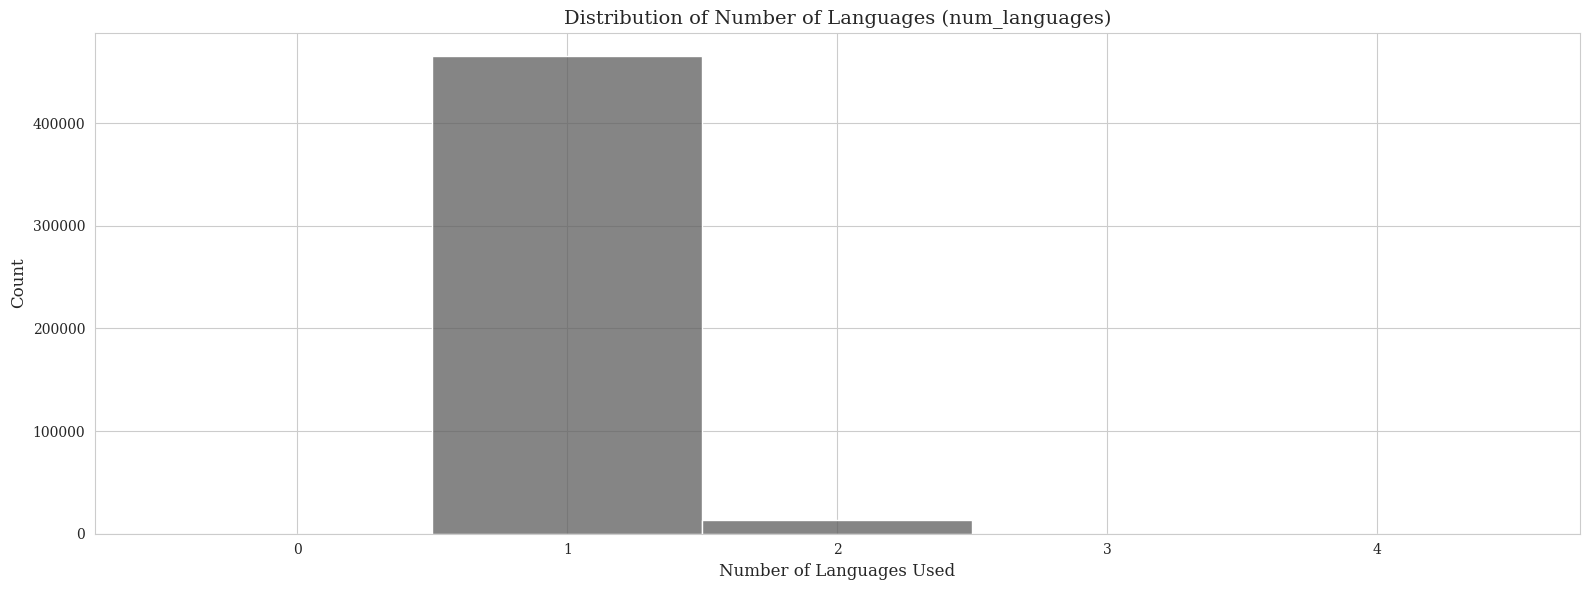

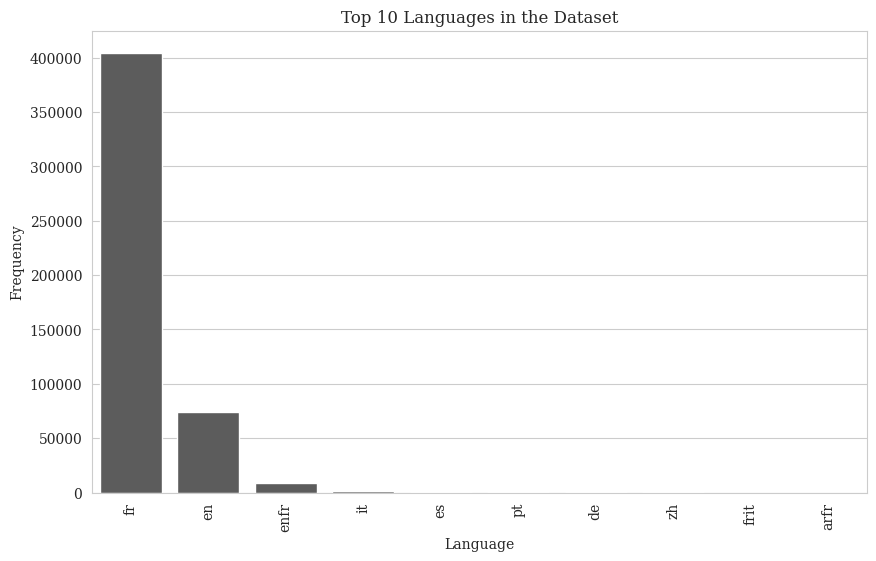

In [29]:
# Set up the figure with subplots
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the distribution of `num_languages` with discrete bins
sns.histplot(df['num_languages'], bins=range(df['num_languages'].min(), df['num_languages'].max() + 2), 
             ax=ax, color=sns.color_palette("Greys_r")[1], kde=False, discrete=True)
ax.set_title('Distribution of Number of Languages (num_languages)', fontsize=14)
ax.set_xlabel('Number of Languages Used', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(range(df['num_languages'].min(), df['num_languages'].max() + 1))  # Show only integers on x-axis

# Adjust spacing
plt.tight_layout()

# Show the plots
plt.show()

# List of language columns (adjust this to match your dataset)
language_columns = [col for col in df.columns if col.startswith('langue')]

# Flatten the data and count frequencies of languages
languages = pd.concat([df[col] for col in language_columns]).dropna()  # Drop missing values

# Get the count of each language
language_counts = languages.value_counts()

# Get the top 10 most frequent languages
top_n_languages = language_counts.head(10)

# Plot the top N languages
plt.figure(figsize=(10, 6))
sns.barplot(x=top_n_languages.index, y=top_n_languages.values, color=sns.color_palette("Greys_r")[1])
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title('Top 10 Languages in the Dataset')
plt.xlabel('Language')
plt.ylabel('Frequency')
plt.show()

## Frequency of disciplines

In [30]:
discipline_counts = df['discipline'].value_counts()
top_30_disciplines = discipline_counts.head(30)

discipline_df = top_30_disciplines.reset_index()
discipline_df.columns = ['Discipline', 'Frequency']

pd.set_option('display.max_rows', 30)
discipline_df


,Discipline,Frequency
0,Médecine,22854
1,Informatique,17239
2,Physique,17113
3,Chimie,11436
4,Sciences économiques,10142
5,Sciences biologiques et fondamentales appliqué...,8818
6,Sciences appliquées,8790
7,Histoire,7810
8,Sciences de gestion,7013
9,Pharmacie,6629


In [31]:
discipline_translations = {
    'Médecine': 'Medicine',
    'Physique': 'Physics',
    'Informatique': 'Computer Science',
    'Chimie': 'Chemistry',
    'Sciences économiques': 'Economics',
    'Sciences biologiques et fondamentales appliquées. Psychologie': 'Applied Biology / Fundamental Sciences',
    'Sciences appliquées': 'Applied Sciences',
    'Histoire': 'History',
    'Pharmacie': 'Pharmacy',
    'Sciences de gestion': 'Management',
    'Sociologie': 'Sociology',
    'Psychologie': 'Psychology',
    'Droit public': 'Public Law',
    'Mathématiques': 'Mathematics',
    'Droit privé': 'Private Law',
    'Droit': 'Law',
    'Philosophie': 'Philosophy',
    'Géographie': 'Geography',
    "Sciences de l'éducation": 'Education Sciences',
    'Neurosciences': 'Neuroscience',
    'Mécanique': 'Mechanics',
    'Terre, océan, espace': 'Earth, Ocean and Space',
    'Littérature française': 'French Literature',
    'Mathématiques appliquées': 'Applied Mathematics',
    'Sciences médicales': 'Medical Sciences',
    'Science politique': 'Political Science',
    'Biologie': 'Biology',
    'Sciences du langage': 'Language Sciences',
    'Sciences': 'Science',
    'Linguistique': 'Linguistics'
}

discipline_df["Discipline"] = discipline_df.Discipline.map(discipline_translations)
discipline_df

,Discipline,Frequency
0,Medicine,22854
1,Computer Science,17239
2,Physics,17113
3,Chemistry,11436
4,Economics,10142
5,Applied Biology / Fundamental Sciences,8818
6,Applied Sciences,8790
7,History,7810
8,Management,7013
9,Pharmacy,6629


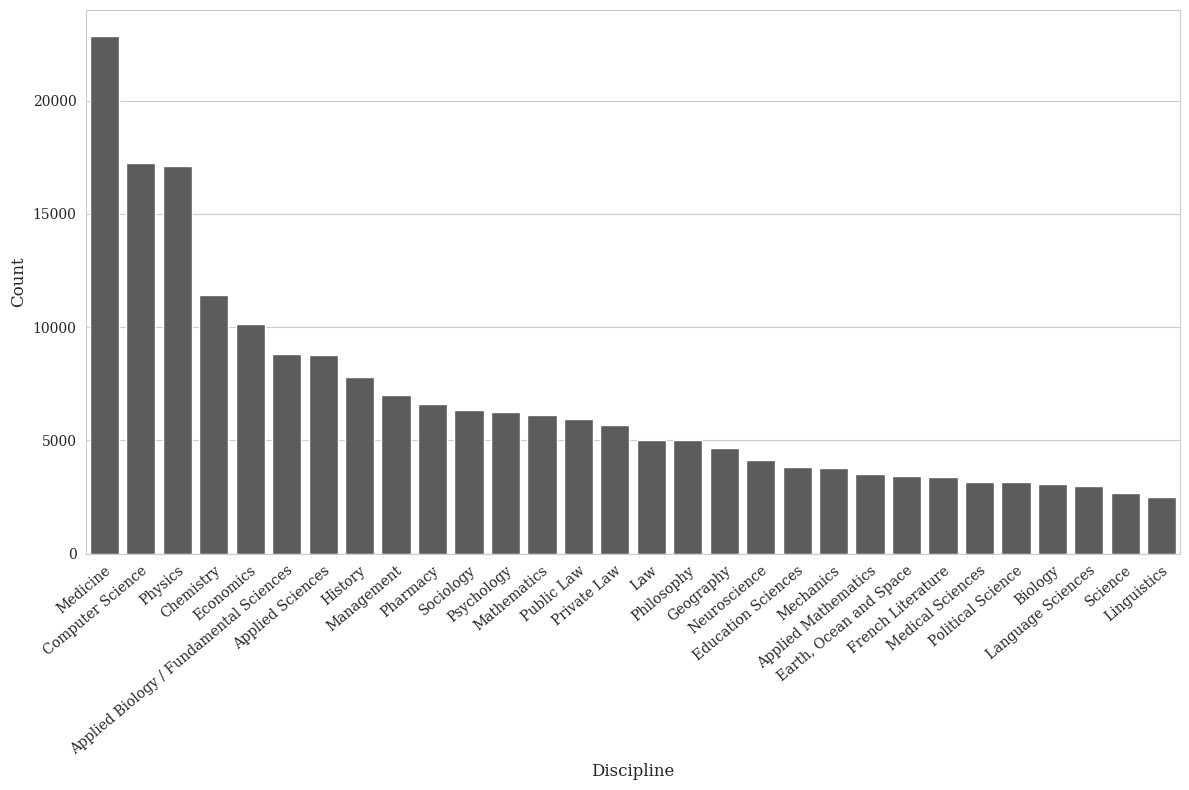

In [32]:
plt.figure(figsize=(12, 8))
sns.barplot(x=discipline_df.Discipline, y=discipline_df.Frequency, color=sns.color_palette("Greys_r")[1], legend=False)

plt.xticks(rotation=40, ha="right", rotation_mode='anchor')
# plt.title('Top 30 Disciplines')
plt.xlabel('Discipline', fontsize="large")
plt.ylabel('Count', fontsize="large")

plt.tight_layout()

# plt.savefig("plots/Discipline_distribution.pdf", dpi=200)
plt.show()


## Distribution of theses per year

In [33]:
df["year"] = df.date_soutenance.dt.year.astype(int)

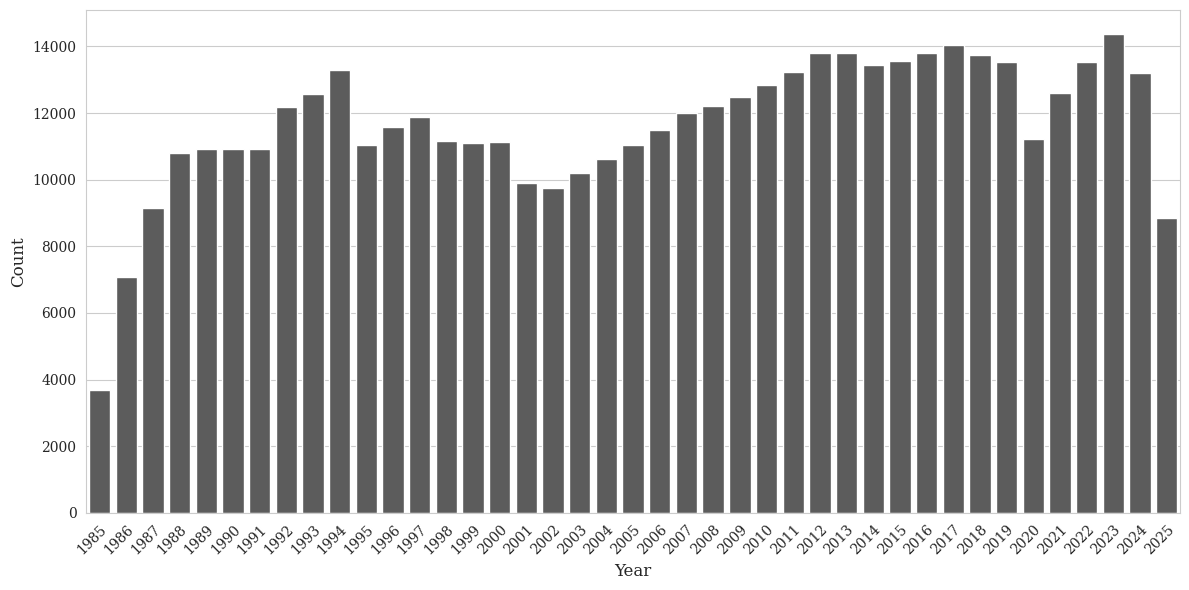

In [34]:
theses_per_year = df.year.value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=theses_per_year.index, y=theses_per_year.values, color=sns.color_palette("Greys_r")[1], legend=False)

plt.xticks(rotation=45, ha="right", rotation_mode='anchor')
plt.xlabel('Year', fontsize="large")
plt.ylabel('Count', fontsize="large")

plt.tight_layout()

# plt.savefig("plots/Theses_per_year.pdf", dpi=200)
plt.show()

## Distribution of the number of Ph. D. supervisors, jury members and thesis rapporteurs for each decade

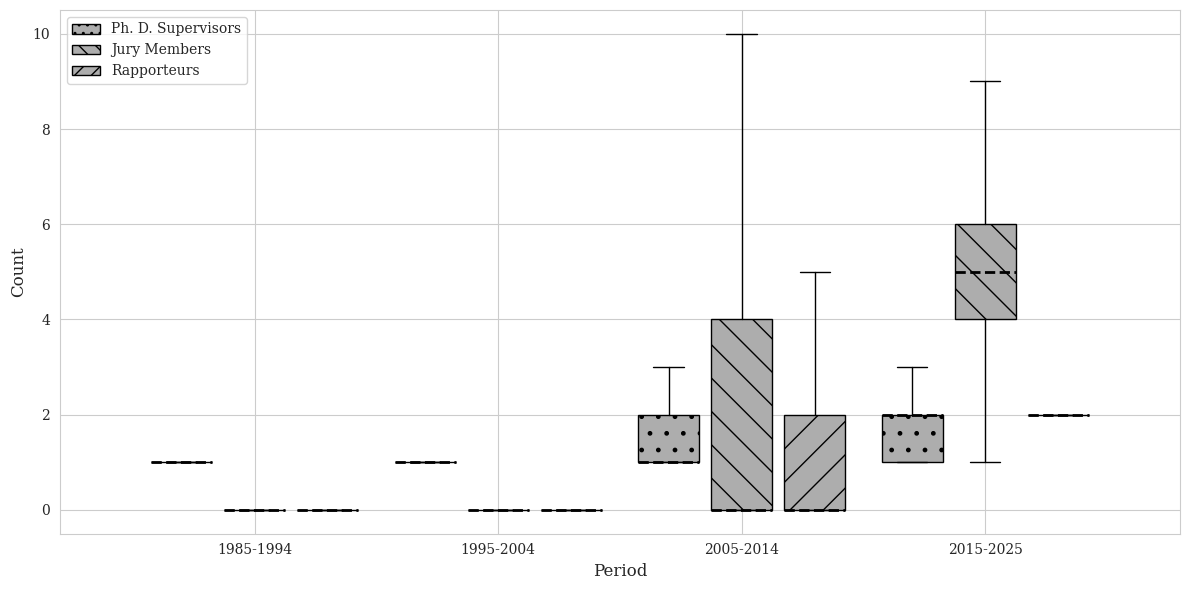

In [ ]:
bins = [1985, 1995, 2005, 2015, 2026]
labels = [f"{b}-{b+9}" if b < bins[-2] else f"{b}-{b+10}" for b in bins[:-1]]
df['period'] = pd.cut(df['year'], bins=bins, labels=labels, right=False)

periods = df['period'].cat.categories

data_directors = [df[df['period'] == p]['num_directeurs'].dropna() for p in periods]
data_jury = [df[df['period'] == p]['num_membres_jury'].dropna() for p in periods]
data_rapporteurs = [df[df['period'] == p]['num_rapporteurs'].dropna() for p in periods]

x = np.arange(len(periods))
width = 0.25
padding = 0.05

plt.figure(figsize=(12, 6))

box1 = plt.boxplot(data_directors, positions=x - width - padding, widths=width, patch_artist=True, showfliers=False)
box2 = plt.boxplot(data_jury, positions=x, widths=width, patch_artist=True, showfliers=False)
box3 = plt.boxplot(data_rapporteurs, positions=x + width + padding, widths=width, patch_artist=True, showfliers=False)

for box, median in zip(box1['boxes'], box1["medians"]):
    box.set_facecolor(sns.color_palette("Greys")[2])
    box.set_hatch('.')
    median.set_color("k")
    median.set_linestyle("--")
    median.set_linewidth(median.get_linewidth() * 2)
for box, median in zip(box2['boxes'], box2["medians"]):
    box.set_facecolor(sns.color_palette("Greys")[2])
    box.set_hatch('\\')
    median.set_color("k")
    median.set_linestyle("--")
    median.set_linewidth(median.get_linewidth() * 2)
for box, median in zip(box3['boxes'], box3["medians"]):
    box.set_facecolor(sns.color_palette("Greys")[2])
    box.set_hatch('/')
    median.set_color("k")
    median.set_linestyle("--")
    median.set_linewidth(median.get_linewidth() * 2)

# 4. Labels and formatting
plt.xticks(x, periods)
plt.xlabel("Period", fontsize="large")
plt.ylabel("Count", fontsize="large")

# Custom legend
plt.fill_between([], [], label='Ph. D. Supervisors', fc=sns.color_palette("Greys")[2], ec="k", hatch='..')
plt.fill_between([], [], label='Jury Members', fc=sns.color_palette("Greys")[2], ec="k", hatch='\\\\')
plt.fill_between([], [], label='Rapporteurs', fc=sns.color_palette("Greys")[2], ec="k", hatch='//')
plt.legend()

plt.tight_layout()
# plt.savefig("plots/Distribution_persons_per_period.pdf", dpi=200)
plt.show()

## Average number of thesis-related roles per year

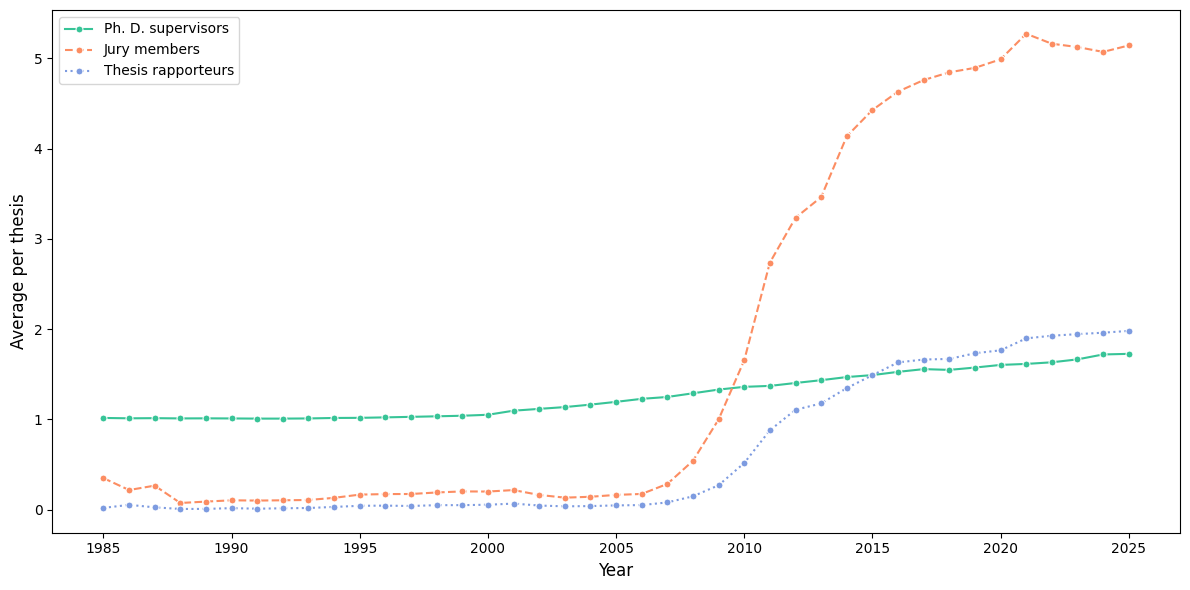

In [18]:
avg_dir  = df.groupby(by="year").num_directeurs.mean()
avg_jury = df.groupby(by="year").num_membres_jury.mean()
avg_rapp = df.groupby(by="year").num_rapporteurs.mean()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=avg_dir.index,  y=avg_dir.values,  marker="o", markersize=5, linestyle="-",  color="#37c497", ax=ax, label="Ph. D. supervisors")
sns.lineplot(x=avg_jury.index, y=avg_jury.values, marker="o", markersize=5, linestyle="--", color="#fc8d62", ax=ax, label="Jury members")
sns.lineplot(x=avg_rapp.index, y=avg_rapp.values, marker="o", markersize=5, linestyle=":",  color="#7d9be0", ax=ax, label="Thesis rapporteurs")

ax.set_xlabel("Year", fontsize="large")
ax.set_ylabel("Average per thesis", fontsize="large")

fig.tight_layout()
# fig.savefig("plots/Avg_persons_per_year.pdf", dpi=200)
plt.show()